# Real Datasets Skimpy Exploration (before splitting)

Compact exploration of the four raw real datasets used in the experiments: cars, spotify, bike, and cows.
We call them raw because they are the underlying data that will then be split into train/validation/test for multiple different seeds.
So all the seeds and both prediction scenarios (in-context and few-shot) will get this same raw dataset, and just the splits differ.
**After splitting, the continous features are then standardized, the categorical features are one-hot encoded, and features with `NaN` values
are imputed.**

Each section lists features, then uses `skimpy` to show feature and response distributions. 
The final small table/plot in each section summarizes the group-size distribution.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from skimpy import skim
from src.data.data_layout import RAW_DATA_FOLDER
from src.constants import GROUPING_COLUMN_NAME, RESPONSE_COLUMN_NAME

RAW_REAL_DATA_FOLDER = RAW_DATA_FOLDER / "real"

## Cars

Feature names: `manufacturer`, `year`, `condition`, `odometer`, `transmission`, `drive`, `lat`, `long`.

Response to predict: `log_price` (stored as `response`).

Group variable: car model id (stored as `group`).

Cars features: ['manufacturer', 'year', 'condition', 'odometer', 'transmission', 'drive', 'lat', 'long']


,manufacturer,year,condition,odometer,transmission,drive,lat,long,log_price
0,gmc,2014.0,good,57923.0,other,None,32.59,-85.48,10.421984
1,chevrolet,2010.0,good,71229.0,other,None,32.59,-85.48,10.025263
2,chevrolet,2020.0,good,19160.0,other,None,32.59,-85.48,10.586332
3,chevrolet,2016.0,good,29499.0,other,4wd,32.59,-85.48,10.451320
4,chevrolet,2016.0,good,17302.0,other,4wd,32.59,-85.48,10.308619


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 72518  │ │ float64     │ 5     │                                                          │
│ │ Number of columns │ 9      │ │ string      │ 4     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column    ┃ NA  ┃ NA %            ┃ mean   ┃ sd     ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │ year      │   0 │               0 │   2013 │  5.723 │   1926 │   2010 │   2014 │   2017 │    2022 │     ▁▇ │  │
│ │ odometer  │ 446 │ 0.6150197192421 │  96120 │  62370 │      0 │  49330 │  93340 │ 133000 │ 2712000 │   ▇    │  │
│ │           │     │             192 │        │        │        │        │        │        │         │        │  │
│ │ lat       │   0 │               0 │   38.6 │  5.204 │  24.67 │  35.11 │  39.36 │  42.35 │   48.96 │ ▂▂▅▇▇▃ │  │
│ │ long      │   0 │               0 │ -95.13 │  16.94 │ -124.3 │ -112.1 │ -90.45 │ -81.49 │  -67.84 │ ▇▂▃▅▇▅ │  │
│ │ log_price │   0 │               0 │  9.564 │ 0.7336 │  6.908 │  9.083 │  9.615 │  10.11 │   12.32 │  ▂▇▇▂  │  │
│ └───────────┴─────┴─────────────────┴────────┴────────┴────────┴────────┴────────┴────────┴─────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃          ┃       ┃           ┃          ┃          ┃           ┃         ┃ chars    ┃ words per ┃ total    ┃  │
│ ┃ column   ┃ NA    ┃ NA %      ┃ shortest ┃ longest  ┃ min       ┃ max     ┃ per row  ┃ row       ┃ words    ┃  │
│ ┡━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩  │
│ │ manufact │     0 │         0 │ gmc      │ chevrole │ bmw       │ toyota  │     5.23 │         1 │    72518 │  │
│ │ urer     │       │           │          │ t        │           │         │          │           │          │  │
│ │ conditio │ 35107 │ 48.411428 │ new      │ excellen │ excellent │ salvage │     7.02 │      0.55 │    39675 │  │
│ │ n        │       │  88662125 │          │ t        │           │         │          │           │          │  │
│ │ transmis │   717 │ 0.9887200 │ other    │ automati │ automatic │ other   │      8.6 │      0.99 │    71801 │  │
│ │ sion     │       │ 419206266 │          │ c        │           │         │          │           │          │  │
│ │ drive    │ 15834 │ 21.834579 │ 4wd      │ 4wd      │ 4wd       │ rwd     │        3 │      0.78 │    56684 │  │
│ │          │       │ 001075596 │          │          │           │         │          │           │          │  │
│ └──────────┴───────┴───────────┴──────────┴──────────┴───────────┴─────────┴──────────┴───────────┴──────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

,count,mean,std,min,25%,50%,75%,max
group_size,1255.0,57.783267,127.138721,10.0,13.0,20.0,42.0,2188.0


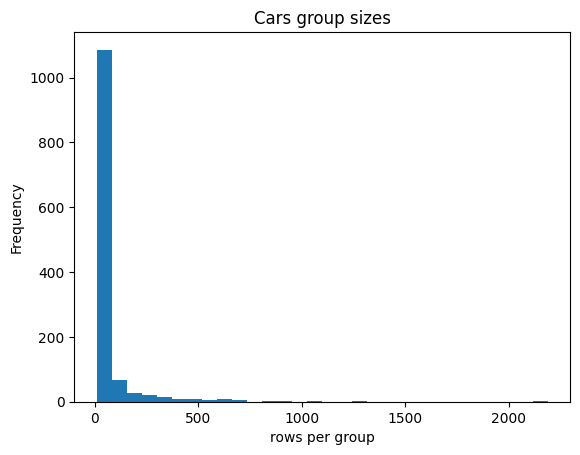

In [2]:
cars = pd.read_parquet(RAW_REAL_DATA_FOLDER / "cars" / "log_price.parquet")

cars_features = cars.columns.drop([GROUPING_COLUMN_NAME, RESPONSE_COLUMN_NAME]).tolist()
print(f"Cars features: {cars_features}")

cars_view = cars[cars_features + [RESPONSE_COLUMN_NAME]].rename(columns={RESPONSE_COLUMN_NAME: "log_price"})
display(cars_view.head())
skim(cars_view)

cars_group_sizes = cars.groupby(GROUPING_COLUMN_NAME).size().rename("group_size")
display(cars_group_sizes.describe(percentiles=[0.25, 0.5, 0.75]).to_frame().T)
cars_group_sizes.plot.hist(bins=30, title="Cars group sizes")
plt.xlabel("rows per group")
plt.show()

## Spotify

Feature names: `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `duration_ms`, `playlist_genre`, `key`, `mode`.

Response to predict: `danceability` (stored as `response`).

Group variable: artist id (stored as `group`).

Spotify features: ['energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'playlist_genre', 'key', 'mode']


,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,key,mode,danceability
0,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754.0,pop,6,1,0.748
1,0.815,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600.0,pop,11,1,0.726
2,0.931,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616.0,pop,1,0,0.675
3,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093.0,pop,7,1,0.718
4,0.919,-5.385,0.1270,0.0799,0.000000,0.1430,0.585,124.982,163049.0,pop,8,1,0.675


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 7868   │ │ float64     │ 10    │                                                          │
│ │ Number of columns │ 13     │ │ int64       │ 2     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column            ┃ NA ┃ NA % ┃ mean    ┃ sd     ┃ p0      ┃ p25    ┃ p50      ┃ p75     ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ energy            │  0 │    0 │  0.6971 │  0.174 │  0.0455 │  0.584 │    0.717 │  0.8322 │  0.996 │  ▁▃▆▇▅ │  │
│ │ loudness          │  0 │    0 │  -6.787 │  2.878 │  -25.36 │ -8.244 │   -6.269 │   -4.77 │  0.642 │   ▁▃▇▁ │  │
│ │ speechiness       │  0 │    0 │  0.1137 │ 0.1077 │  0.0224 │ 0.0404 │   0.0643 │    0.15 │  0.869 │  ▇▂▁   │  │
│ │ acousticness      │  0 │    0 │  0.1636 │ 0.2015 │ 1.4e-06 │ 0.0192 │   0.0789 │  0.2333 │  0.992 │  ▇▂▁▁  │  │
│ │ instrumentalness  │  0 │    0 │ 0.04192 │ 0.1515 │       0 │      0 │ 5.14e-06 │ 0.00115 │  0.983 │   ▇    │  │
│ │ liveness          │  0 │    0 │  0.1998 │ 0.1642 │ 0.00936 │ 0.0929 │    0.134 │   0.268 │  0.996 │  ▇▃▁   │  │
│ │ valence           │  0 │    0 │  0.5342 │ 0.2259 │  0.0294 │  0.363 │     0.54 │  0.7112 │  0.978 │ ▂▅▇▇▇▃ │  │
│ │ tempo             │  0 │    0 │     120 │  28.92 │   53.95 │  96.12 │    118.1 │     136 │    220 │ ▁▇▇▃▂  │  │
│ │ duration_ms       │  0 │    0 │  236500 │  59740 │   31430 │ 198800 │   228500 │  267300 │ 517800 │   ▃▇▃  │  │
│ │ key               │  0 │    0 │   5.353 │  3.638 │       0 │      2 │        6 │       9 │     11 │ ▇▃▅▆▆▅ │  │
│ │ mode              │  0 │    0 │  0.5782 │ 0.4939 │       0 │      0 │        1 │       1 │      1 │ ▆    ▇ │  │
│ │ danceability      │  0 │    0 │  0.6491 │ 0.1528 │    0.13 │  0.548 │     0.67 │   0.763 │  0.977 │  ▂▅▇▇▂ │  │
│ └───────────────────┴────┴──────┴─────────┴────────┴─────────┴────────┴──────────┴─────────┴────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest ┃ min ┃ max  ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ playlist_genre │  0 │    0 │ pop      │ latin   │ edm │ rock │           3.5 │             1 │        7868 │  │
│ └────────────────┴────┴──────┴──────────┴─────────┴─────┴──────┴───────────────┴───────────────┴─────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

,count,mean,std,min,25%,50%,75%,max
group_size,418.0,18.822967,11.799372,10.0,12.0,15.0,21.0,130.0


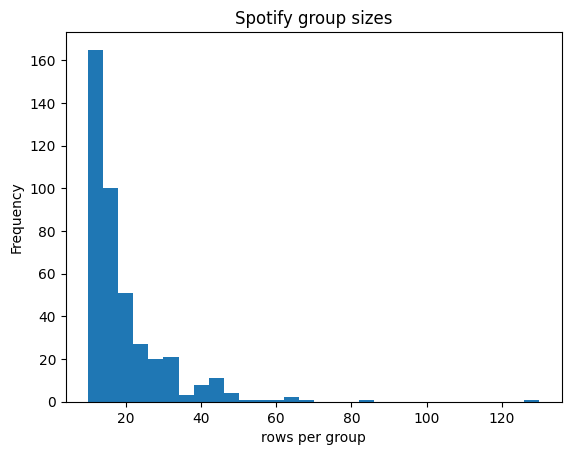

In [3]:
spotify = pd.read_parquet(RAW_REAL_DATA_FOLDER / "spotify" / "danceability.parquet")
spotify_features = spotify.columns.drop([GROUPING_COLUMN_NAME, RESPONSE_COLUMN_NAME]).tolist()
print(f"Spotify features: {spotify_features}")

spotify_view = spotify[spotify_features + [RESPONSE_COLUMN_NAME]].rename(columns={RESPONSE_COLUMN_NAME: "danceability"})
display(spotify_view.head())
skim(spotify_view)

spotify_group_sizes = spotify.groupby(GROUPING_COLUMN_NAME).size().rename("group_size")
display(spotify_group_sizes.describe(percentiles=[0.25, 0.5, 0.75]).to_frame().T)
spotify_group_sizes.plot.hist(bins=30, title="Spotify group sizes")
plt.xlabel("rows per group")
plt.show()

## Bike

Feature names: `hour_sin`, `hour_cos`, `day_of_week_sin`, `day_of_week_cos`, `day_of_year_sin`, `day_of_year_cos`, `temperature`, `humidity`, `rainfall`.

Response to predict: `log_count` (stored as `response`).

Group variable: date (stored as `group`).

Bike features: ['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos', 'temperature', 'humidity', 'rainfall']


,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos,temperature,humidity,rainfall,log_count
0,0.000000,1.000000,-0.433884,-0.900969,-0.497204,0.867634,-5.2,37,0.0,5.541264
1,0.258819,0.965926,-0.433884,-0.900969,-0.497204,0.867634,-5.5,38,0.0,5.323010
2,0.500000,0.866025,-0.433884,-0.900969,-0.497204,0.867634,-6.0,39,0.0,5.159055
3,0.707107,0.707107,-0.433884,-0.900969,-0.497204,0.867634,-6.2,40,0.0,4.682131
4,0.866025,0.500000,-0.433884,-0.900969,-0.497204,0.867634,-6.0,36,0.0,4.369448


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 8465   │ │ float64     │ 9     │                                                          │
│ │ Number of columns │ 10     │ │ int64       │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column       ┃ NA ┃ NA % ┃ mean       ┃ sd     ┃ p0      ┃ p25     ┃ p50        ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ hour_sin     │  0 │    0 │ -0.0005077 │ 0.7071 │      -1 │ -0.7071 │          0 │ 0.7071 │      1 │ ▇▂▂▅▂▇ │  │
│ │ hour_cos     │  0 │    0 │ -0.0005077 │ 0.7071 │      -1 │ -0.7071 │ -1.837e-16 │ 0.7071 │      1 │ ▇▂▃▃▂▇ │  │
│ │ day_of_week_ │  0 │    0 │  -0.009838 │ 0.7049 │ -0.9749 │ -0.7818 │          0 │ 0.7818 │ 0.9749 │ ▇▅ ▅▃▇ │  │
│ │ sin          │    │      │            │        │         │         │            │        │        │        │  │
│ │ day_of_week_ │  0 │    0 │  0.0009014 │ 0.7094 │  -0.901 │  -0.901 │    -0.2225 │ 0.6235 │      1 │ ▇ ▇ ▇▅ │  │
│ │ cos          │    │      │            │        │         │         │            │        │        │        │  │
│ │ day_of_year_ │  0 │    0 │    0.02239 │ 0.6978 │      -1 │ -0.6645 │     0.0344 │ 0.7113 │      1 │ ▇▃▃▃▃▇ │  │
│ │ sin          │    │      │            │        │         │         │            │        │        │        │  │
│ │ day_of_year_ │  0 │    0 │    -0.0027 │ 0.7161 │      -1 │ -0.7225 │   0.001075 │  0.724 │      1 │ ▇▃▃▃▃▇ │  │
│ │ cos          │    │      │            │        │         │         │            │        │        │        │  │
│ │ temperature  │  0 │    0 │      12.77 │   12.1 │   -17.8 │       3 │       13.5 │   22.7 │   39.4 │ ▁▅▇▇▇▂ │  │
│ │ humidity     │  0 │    0 │      58.15 │  20.48 │       0 │      42 │         57 │     74 │     98 │  ▃▇▇▆▅ │  │
│ │ rainfall     │  0 │    0 │     0.1491 │  1.126 │       0 │       0 │          0 │      0 │     35 │   ▇    │  │
│ │ log_count    │  0 │    0 │      6.093 │  1.154 │   1.099 │   5.371 │      6.297 │  6.989 │  8.177 │   ▂▆▇▅ │  │
│ └──────────────┴────┴──────┴────────────┴────────┴─────────┴─────────┴────────────┴────────┴────────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

,count,mean,std,min,25%,50%,75%,max
group_size,353.0,23.98017,0.372572,17.0,24.0,24.0,24.0,24.0


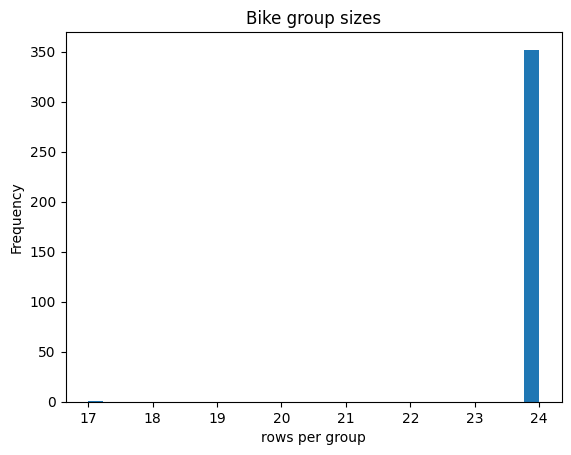

In [4]:
bike = pd.read_parquet(RAW_REAL_DATA_FOLDER / "bike" / "log_count.parquet")
bike_features = bike.columns.drop([GROUPING_COLUMN_NAME, RESPONSE_COLUMN_NAME]).tolist()
print(f"Bike features: {bike_features}")

bike_view = bike[bike_features + [RESPONSE_COLUMN_NAME]].rename(columns={RESPONSE_COLUMN_NAME: "log_count"})
display(bike_view.head())
skim(bike_view)

bike_group_sizes = bike.groupby(GROUPING_COLUMN_NAME).size().rename("group_size")
display(bike_group_sizes.describe(percentiles=[0.25, 0.5, 0.75]).to_frame().T)
bike_group_sizes.plot.hist(bins=30, title="Bike group sizes")
plt.xlabel("rows per group")
plt.show()

## Cows

Feature names: `time`, `diet`.

Response to predict: `protein` (stored as `response`).

Group variable: cow id (stored as `group`).

Cows features: ['time', 'diet']


,time,diet,protein
0,1,barley,3.63
1,2,barley,3.57
2,3,barley,3.47
3,4,barley,3.65
4,5,barley,3.89


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1337   │ │ int64       │ 1     │                                                          │
│ │ Number of columns │ 3      │ │ string      │ 1     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃ column      ┃ NA   ┃ NA %    ┃ mean     ┃ sd        ┃ p0     ┃ p25   ┃ p50    ┃ p75    ┃ p100   ┃ hist     ┃  │
│ ┡━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━┩  │
│ │ time        │    0 │       0 │    9.185 │     5.167 │      1 │     5 │      9 │     13 │     19 │  ▇▇▇▇▇▆  │  │
│ │ protein     │    0 │       0 │    3.422 │    0.3318 │   2.45 │   3.2 │   3.41 │   3.63 │   4.59 │  ▁▃▇▆▂   │  │
│ └─────────────┴──────┴─────────┴──────────┴───────────┴────────┴───────┴────────┴────────┴────────┴──────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃        ┃    ┃      ┃          ┃              ┃        ┃        ┃ chars per    ┃ words per    ┃             ┃  │
│ ┃ column ┃ NA ┃ NA % ┃ shortest ┃ longest      ┃ min    ┃ max    ┃ row          ┃ row          ┃ total words ┃  │
│ ┡━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ diet   │  0 │    0 │ barley   │ barley+lupin │ barley │ lupins │          8.4 │            1 │        1337 │  │
│ │        │    │      │          │ s            │        │        │              │              │             │  │
│ └────────┴────┴──────┴──────────┴──────────────┴────────┴────────┴──────────────┴──────────────┴─────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

,count,mean,std,min,25%,50%,75%,max
group_size,79.0,16.924051,2.319218,12.0,14.0,18.0,19.0,19.0


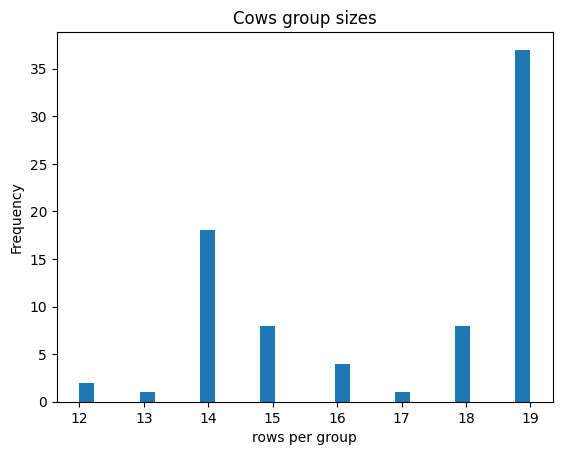

In [5]:
cows = pd.read_parquet(RAW_REAL_DATA_FOLDER / "cows" / "protein.parquet")
cows_features = cows.columns.drop([GROUPING_COLUMN_NAME, RESPONSE_COLUMN_NAME]).tolist()
print(f"Cows features: {cows_features}")

cows_view = cows[cows_features + [RESPONSE_COLUMN_NAME]].rename(columns={RESPONSE_COLUMN_NAME: "protein"})
display(cows_view.head())
skim(cows_view)

cows_group_sizes = cows.groupby(GROUPING_COLUMN_NAME).size().rename("group_size")
display(cows_group_sizes.describe(percentiles=[0.25, 0.5, 0.75]).to_frame().T)
cows_group_sizes.plot.hist(bins=30, title="Cows group sizes")
plt.xlabel("rows per group")
plt.show()